# PHẦN 4: HUẤN LUYỆN XẾP HẠNG VÀ ĐÁNH GIÁ


In [1]:
import os, pandas as pd, numpy as np, xgboost as xgb, math
import pyarrow.parquet as pq

In [3]:
FEAT_OUT = '../data/processed/features.parquet'
TEST_PATH = '../data/processed/test_interactions.csv'
CAND_PATH = '../data/processed/candidates_phase2.csv'

XGBoost Parameterized Training Complete.


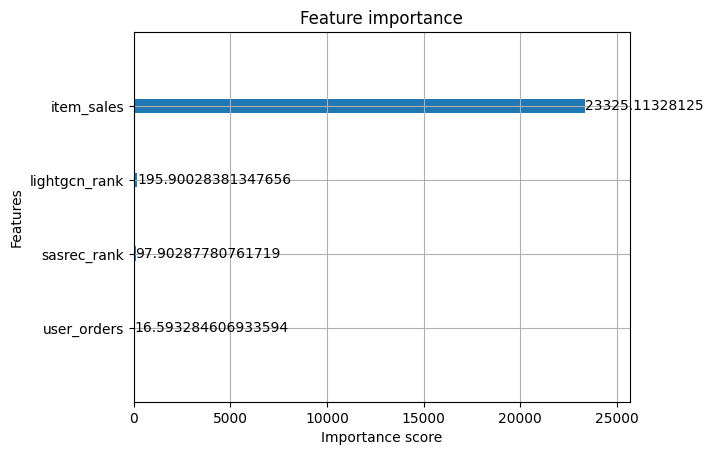

In [4]:
class ParquetIter(xgb.core.DataIter):
    def __init__(self, path):
        self.path = path
        self.pf = pq.ParquetFile(self.path)
        self.it = self.pf.iter_batches(batch_size=100000)
        super().__init__()
    def next(self, input_data):
        try:
            batch = next(self.it)
            chunk = batch.to_pandas()
            input_data(data=chunk.drop(columns=['label', 'mapped_user_id', 'mapped_item_id']), label=chunk['label'])
            return 1
        except StopIteration:
            return 0
    def reset(self):
        self.it = self.pf.iter_batches(batch_size=100000)

it = ParquetIter(FEAT_OUT)
# DMatrix configured missing=np.nan as specific user req
dtrain = xgb.ExtMemQuantileDMatrix(it, missing=np.nan)

params = {'objective': 'binary:logistic', 'eval_metric': 'logloss', 'max_depth': 4}
model = xgb.train(params, dtrain, num_boost_round=10)
print("XGBoost Parameterized Training Complete.")



import matplotlib.pyplot as plt

# Visualization of Feature Importance
xgb.plot_importance(model, importance_type='gain')
plt.show()

In [5]:
# Evaluator directly working on Big Chunk iteration over Candidates
dtypes_cand = {'mapped_user_id': 'int32', 'mapped_item_id': 'int32', 'sasrec_rank': 'float32', 'lightgcn_rank': 'float32'}

# Small cache for User_Orders & Item_Sales to prevent re-reading parquet
df_use = pd.read_parquet(FEAT_OUT, columns=['mapped_user_id', 'user_orders']).drop_duplicates()
df_ite = pd.read_parquet(FEAT_OUT, columns=['mapped_item_id', 'item_sales', 'price']).drop_duplicates()

reader = pd.read_csv(CAND_PATH, dtype=dtypes_cand, chunksize=500000)
all_top100 = []

for chunk in reader:
    chunk = pd.merge(chunk, df_use, on='mapped_user_id', how='left')
    chunk = pd.merge(chunk, df_ite, on='mapped_item_id', how='left')
    chunk.fillna({'price': 0, 'user_orders': 0, 'item_sales': 0}, inplace=True)
    
    X_cands = chunk[['user_orders', 'item_sales', 'price', 'sasrec_rank', 'lightgcn_rank']]
    dtest = xgb.DMatrix(X_cands, missing=np.nan)
    chunk['score'] = model.predict(dtest)
    
    sub = chunk[['mapped_user_id', 'mapped_item_id', 'score']].sort_values(['mapped_user_id', 'score'], ascending=[True, False])
    all_top100.append(sub.groupby('mapped_user_id').head(100))

# To heavily support chunk boundary safety, union and re-sort local top100 chunks.
final_cands = pd.concat(all_top100, ignore_index=True)
final_cands = final_cands.sort_values(['mapped_user_id', 'score'], ascending=[True, False])
top100 = final_cands.groupby('mapped_user_id').head(100)

df_test = pd.read_csv(TEST_PATH)
truth = df_test.groupby('mapped_user_id')['mapped_item_id'].apply(set).to_dict()

hits_10, ndcg_10, recall_100, valid_users = 0, 0, 0, 0
for u, group in top100.groupby('mapped_user_id'):
    if u not in truth: continue
    valid_users += 1
    t = truth[u]
    
    u_hit, u_ndcg, u_rec = 0, 0, 0
    for rank, item in enumerate(group['mapped_item_id']):
        if item in t:
            u_rec += 1
            if rank < 10:
                u_hit = 1
                u_ndcg += 1.0 / math.log2(rank + 2)
    hits_10 += u_hit
    ndcg_10 += u_ndcg
    recall_100 += u_rec / len(t)

print(f"HR@10: {hits_10/valid_users:.4f}")
print(f"NDCG@10: {ndcg_10/valid_users:.4f}")
print(f"Recall@100: {recall_100/valid_users:.4f}")

HR@10: 0.0013
NDCG@10: 0.0011
Recall@100: 0.0055
